# Sesión de clase 08 · Laboratorio: polarización de sentimiento por tópico

**Contexto:** la tienda quiere saber **qué temas dividen a sus clientes**.
Para cada tópico calcularemos el sentimiento neto y la polarización, y con
ellos una matriz de priorización.

```
comentarios.csv  →  BERTopic  →  pysentimiento  →  tabla por tópico  →  gráficos
  135 textos        tópico por     POS · NEU · NEG   n, %POS, %NEG,       barras apiladas y
                    comentario                       neto, polarización   matriz de priorización
```

**Datos:** `data/comentarios.csv` — 135 comentarios · 96 clientes · 7 países ·
calificación 1–5★ · fechas de 2024-01 a 2026-08.

**Etapas:** A. Tópicos · B. Sentimiento · C. Validación · D. Polarización ·
E. Análisis · Preguntas de reflexión · Reto opcional.

Las tablas (`.csv`) y gráficos (`.html` y `.png`) se guardan en `salidas/`.

In [1]:
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance
from hdbscan import HDBSCAN
from pysentimiento import create_analyzer
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import (ConfusionMatrixDisplay, classification_report,
                             cohen_kappa_score, f1_score)
from umap import UMAP

pd.set_option("display.max_colwidth", 110)
SALIDAS = Path("../salidas")
SALIDAS.mkdir(exist_ok=True)

CLASES = ["NEG", "NEU", "POS"]
a3 = lambda s: "NEG" if s <= 2 else ("NEU" if s == 3 else "POS")

# Paleta: azul = positivo, rojo = negativo, gris = neutro/referencias
AZUL, ROJO, GRIS, TINTA = "#2a78d6", "#e34948", "#8a8985", "#52514e"
COLOR = {"POS": AZUL, "NEU": "#c9c8c4", "NEG": ROJO}
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GRIS, "axes.labelcolor": TINTA,
    "xtick.color": TINTA, "ytick.color": TINTA,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "figure.dpi": 110,
})

df = pd.read_csv("../data/comentarios.csv")
docs = df["texto"].tolist()
print(df.shape)
df["calificacion"].value_counts().sort_index().rename("comentarios").to_frame().T

(135, 7)


calificacion,1,2,3,4,5
comentarios,17,25,31,30,32


## Etapa A — Tópicos

### A.1 Ajustar BERTopic

Misma configuración del Ejercicio 2: MiniLM multilingüe, UMAP a 5 d con
semilla fija, HDBSCAN con `min_cluster_size=4` y *stopwords* en español solo
para describir los tópicos.

In [2]:
st = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
ruta_emb = SALIDAS / "embeddings.npy"
if ruta_emb.exists():
    embeddings = np.load(ruta_emb)
else:
    embeddings = st.encode(docs, show_progress_bar=True)
    np.save(ruta_emb, embeddings)


def normalizar(texto):
    t = unicodedata.normalize("NFKD", texto.lower())
    return "".join(ch for ch in t if not unicodedata.combining(ch))


STOPWORDS_ES = sorted(set("""
a al algo algun alguna algunas alguno algunos ante antes aqui asi aun aunque
bajo bien cada casi como con contra cual cuando de del desde donde dos durante
e el ella ellas ellos en entre era eran es esa esas ese eso esos esta estaba
estaban estan estar este esto estos fue fueron ha habia han hasta hay he la las
le les lo los mas me mi mis mucho muy nada ni no nos o otra otras otro otros
para pero poco por porque que se ser si sin sobre solo su sus tambien tan tanto
te tiene todo todos tu tuve un una uno unos y ya yo vez veces mismo misma
son podria poder bastante
""".split()))


def vectorizador():
    return CountVectorizer(preprocessor=normalizar, stop_words=STOPWORDS_ES)


topic_model = BERTopic(
    embedding_model=st,
    umap_model=UMAP(n_neighbors=10, n_components=5, min_dist=0.0,
                    metric="cosine", random_state=42),
    hdbscan_model=HDBSCAN(min_cluster_size=4, prediction_data=True),
    vectorizer_model=vectorizador(),
    representation_model={"KeyBERT": KeyBERTInspired(),
                          "MMR": MaximalMarginalRelevance(diversity=0.3)},
)
topicos_orig, _ = topic_model.fit_transform(docs, embeddings)
topicos_orig = np.array(topicos_orig)
print(f"{topicos_orig.max() + 1} tópicos y {(topicos_orig == -1).sum()} comentarios de ruido (−1)")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

9 tópicos y 26 comentarios de ruido (−1)


### A.2 Reducir outliers

Reasignamos los comentarios del tópico −1 al tópico más parecido (estrategia
`"c-tf-idf"`) y actualizamos las palabras de cada tópico. Guardamos ambas
asignaciones: la original la usaremos en la pregunta de reflexión 3.

In [3]:
topicos = np.array(topic_model.reduce_outliers(docs, topicos_orig, strategy="c-tf-idf"))
topic_model.update_topics(docs, topics=topicos.tolist(), vectorizer_model=vectorizador(),
                          representation_model={"KeyBERT": KeyBERTInspired(),
                                                "MMR": MaximalMarginalRelevance(diversity=0.3)})
df["topico_orig"] = topicos_orig
df["topico"] = topicos
print("Comentarios en −1 después de reasignar:", (topicos == -1).sum())

2026-10-06 17:55:41,282 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Comentarios en −1 después de reasignar: 0


### A.3 Nombrar los tópicos

Leemos las palabras clave y tres comentarios de cada tópico y escribimos un
nombre corto. Los nombres de `NOMBRES` corresponden a los tópicos que se
obtienen con esta configuración; **si sus tópicos salen distintos** (otra
versión de las librerías u otro equipo), revisen la tabla y ajusten el
diccionario. Un tópico sin nombre se muestra con sus tres palabras
principales.

In [4]:
info = topic_model.get_topic_info().set_index("Topic")
revision = pd.DataFrame({
    "comentarios": info["Count"],
    "c-TF-IDF": info["Representation"].str[:6].str.join(", "),
    "KeyBERT": info["KeyBERT"].str[:6].str.join(", "),
    "ejemplo": [df.loc[df["topico"] == k, "texto"].iloc[0] for k in info.index],
}).rename_axis("tópico")
revision

,comentarios,c-TF-IDF,KeyBERT,ejemplo
tópico,,,,
0,39,"soporte, correo, pedido, chat, tardo, tiempo","checkout, plazo, correo, correos, cancele, mensaje",El envio internacional tardo mas dias de los indicados originalmente.
1,16,"compra, tienda, envio, puntos, experiencia, tiendas","compras, tiendas, compradores, comprando, tienda, compra","La experiencia de compra en oferta de temporada fue muy fluida, sin caidas del sitio."
2,13,"sitio, buena, atencion, experiencia, general, virtual","virtual, navegar, pagina, experiencia, leer, dificiles",Muy buena atencion personalizada cuando pregunte por disponibilidad de un modelo agotado.
3,19,"producto, marcas, stock, variedad, queria, disponible","compre, compras, tiendas, comprar, compro, oferta",El catalogo de marcas es decente aunque hay ciertos modelos que nunca llegan a tener stock.
4,14,"productos, busqueda, decidir, comparar, anteriores, filtros","buscador, comparar, comparacion, busca, busquedas, productos",El sitio recuerda mis busquedas anteriores y sugiere productos relacionados de forma acertada.
5,12,"registro, proceso, pago, rapido, cuenta, tomo","checkout, registro, credito, facturacion, tarjeta, cuenta",El proceso de facturacion para empresa fue mas simple de lo que esperaba.
6,9,"tecnologia, general, tienda, buena, seguire, proximos","tiendas, tienda, recomendaria, comprando, comprar, preferida","En general cumple lo que promete, ni mejor ni peor que otras tiendas de tecnologia que he probado."
7,6,"app, movil, celular, funciona, rapido, incluso","app, navegador, pantalla, pantallas, celular, botones","La app funciona correctamente la mayoria del tiempo, con alguna que otra pausa al cargar imagenes."
8,7,"conforme, garantia, claro, politicas, principio, comprar","garantia, excelente, compre, comprar, claro, principio",Muy satisfecho con la claridad de las politicas de garantia antes de comprar.


In [5]:
NOMBRES = {
    0: "Reclamos de soporte, cobros y demoras",
    1: "Experiencia de compra y puntos",
    2: "Diseño y navegación del sitio",
    3: "Catálogo, stock y precios",
    4: "Búsqueda, filtros y comparación",
    5: "Pagos, registro y facturación",
    6: "Recomendación de la tienda",
    7: "App móvil",
    8: "Garantías y políticas claras",
}


def nombre(k):
    if k == -1:
        return "Ruido (sin tópico)"
    return NOMBRES.get(k, f"Tópico {k}: " + ", ".join(w for w, _ in topic_model.get_topic(k)[:3]))


topic_model.set_topic_labels({k: nombre(k) for k in info.index})
df["nombre"] = df["topico"].map(nombre)
revision.assign(nombre=[nombre(k) for k in revision.index])[["nombre", "comentarios", "c-TF-IDF"]]

,nombre,comentarios,c-TF-IDF
tópico,,,
0,"Reclamos de soporte, cobros y demoras",39,"soporte, correo, pedido, chat, tardo, tiempo"
1,Experiencia de compra y puntos,16,"compra, tienda, envio, puntos, experiencia, tiendas"
2,Diseño y navegación del sitio,13,"sitio, buena, atencion, experiencia, general, virtual"
3,"Catálogo, stock y precios",19,"producto, marcas, stock, variedad, queria, disponible"
4,"Búsqueda, filtros y comparación",14,"productos, busqueda, decidir, comparar, anteriores, filtros"
5,"Pagos, registro y facturación",12,"registro, proceso, pago, rapido, cuenta, tomo"
6,Recomendación de la tienda,9,"tecnologia, general, tienda, buena, seguire, proximos"
7,App móvil,6,"app, movil, celular, funciona, rapido, incluso"
8,Garantías y políticas claras,7,"conforme, garantia, claro, politicas, principio, comprar"


## Etapa B — Sentimiento con pysentimiento

`pysentimiento` usa **RoBERTuito**, un modelo entrenado con textos en español;
devuelve `POS`, `NEU` o `NEG` con sus probabilidades. Corre localmente (la
primera vez descarga el modelo).

In [6]:
analizador = create_analyzer(task="sentiment", lang="es")
predicciones = analizador.predict(docs)

df["sent"] = [p.output for p in predicciones]
df["confianza"] = [max(p.probas.values()) for p in predicciones]
for c in CLASES:
    df[f"p_{c}"] = [p.probas[c] for p in predicciones]

df[["calificacion", "sent", "confianza", "p_NEG", "p_NEU", "p_POS", "texto"]].head(8).round(2)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/135 [00:00<?, ? examples/s]

,calificacion,sent,confianza,p_NEG,p_NEU,p_POS,texto
0,5,POS,0.55,0.02,0.43,0.55,El proceso de facturacion para empresa fue mas simple de lo que esperaba.
1,3,POS,0.59,0.07,0.35,0.59,"En general cumple lo que promete, ni mejor ni peor que otras tiendas de tecnologia que he probado."
2,4,POS,0.80,0.01,0.19,0.80,"Buena tienda en general, seguire comprando aqui mis proximos equipos."
3,3,NEU,0.60,0.36,0.60,0.03,El envio internacional tardo mas dias de los indicados originalmente.
4,3,NEU,0.72,0.02,0.72,0.26,El proceso de devolucion fue sencillo de iniciar aunque tomo unos dias en confirmarse.
5,5,NEU,0.49,0.02,0.49,0.49,Muy buena atencion personalizada cuando pregunte por disponibilidad de un modelo agotado.
6,4,NEU,0.51,0.02,0.51,0.47,El soporte me oriento bien sobre compatibilidad de accesorios con mi equipo.
7,3,NEU,0.68,0.19,0.68,0.14,El catalogo de marcas es decente aunque hay ciertos modelos que nunca llegan a tener stock.


## Etapa C — Validación contra la calificación

Las estrellas del cliente sirven de referencia: 1–2★ → NEG, 3★ → NEU,
4–5★ → POS.

              precision    recall  f1-score   support

         NEG      0.881     0.881     0.881        42
         NEU      0.548     0.742     0.630        31
         POS      0.902     0.742     0.814        62

    accuracy                          0.785       135
   macro avg      0.777     0.788     0.775       135
weighted avg      0.814     0.785     0.793       135

κ de Cohen = 0.674


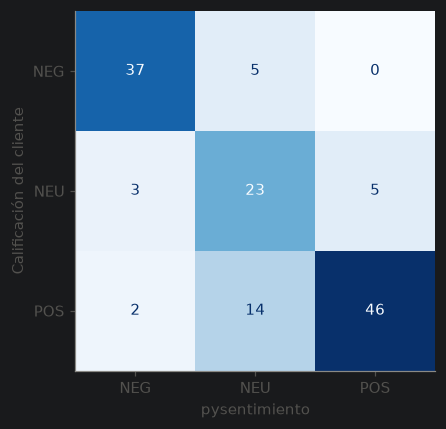

In [19]:
df["y"] = df["calificacion"].map(a3)

print(classification_report(df["y"], df["sent"], labels=CLASES, digits=3))
print(f"κ de Cohen = {cohen_kappa_score(df['y'], df['sent']):.3f}")

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_predictions(df["y"], df["sent"], labels=CLASES, ax=ax,
                                        colorbar=False, cmap="Blues")
ax.set_xlabel("pysentimiento")
ax.set_ylabel("Calificación del cliente")
ax.grid(False)
plt.tight_layout()
plt.savefig(SALIDAS / "matriz_confusion_sentimiento.png")
plt.show()

### ¿En qué comentarios falla?

Los errores más graves son los que confunden **positivo con negativo**. Los
ordenamos por la confianza del modelo:

In [20]:
grave = ((df["y"] == "POS") & (df["sent"] == "NEG")) | ((df["y"] == "NEG") & (df["sent"] == "POS"))
print(f"Errores graves (POS ↔ NEG): {grave.sum()}")
errores = df[df["y"] != df["sent"]].assign(grave=grave)
errores.sort_values(["grave", "confianza"], ascending=False).head(10)[
    ["calificacion", "y", "sent", "confianza", "texto"]].round(2)

Errores graves (POS ↔ NEG): 2


,calificacion,y,sent,confianza,texto
132,4,POS,NEG,0.66,Me parece justo el precio de envio comparado con otras tiendas de electronica.
47,4,POS,NEG,0.51,El checkout como invitado es rapido si no quieres crear una cuenta.
76,3,NEU,NEG,0.90,El diseno del sitio en modo oscuro tiene algunos textos dificiles de leer.
10,3,NEU,POS,0.89,"La experiencia de compra es correcta, sin contratiempos importantes en mis ultimas ordenes."
72,4,POS,NEU,0.86,La opcion de retiro en tienda me ahorro el costo de envio en mi ultima compra.
32,5,POS,NEU,0.86,La confirmacion de pedido llega de inmediato al correo con todos los detalles.
27,5,POS,NEU,0.86,El soporte tecnico me ayudo a elegir entre dos laptops segun mi uso real.
112,3,NEU,NEG,0.82,"El sitio se cayo un momento durante una oferta especial, tuve que reintentar la compra."
24,3,NEU,NEG,0.81,La seccion de preguntas frecuentes no cubre todos los casos que tuve.
79,4,POS,NEU,0.78,Es facil guardar productos en una lista de deseos para comprarlos despues.


Revisen los errores: ¿son fallas del modelo, comentarios **mixtos** («buena
experiencia, aunque…») o calificaciones que no coinciden con el texto?

## Etapa D — Sentimiento neto y polarización por tópico

- **Sentimiento neto** = %POS − %NEG, de −1 (todos negativos) a +1 (todos
  positivos).
- **Polarización** = 2 × mín(%POS, %NEG), de 0 (opiniones homogéneas) a 1
  (clientes divididos en dos mitades).

El mismo neto puede esconder lecturas distintas: 44 % POS / 44 % NEG y
10 % POS / 10 % NEG tienen ambos neto 0, pero el primero tiene polarización
0.88 (clientes divididos) y el segundo 0.20 (clientes indiferentes).

In [21]:
def tabla_por_topico(datos, col_topico="nombre", col_sent="sent"):
    t = pd.crosstab(datos[col_topico], datos[col_sent], normalize="index").reindex(
        columns=CLASES, fill_value=0)
    t.columns = [f"%{c}" for c in CLASES]
    t.insert(0, "n", datos[col_topico].value_counts())
    t["neto"] = t["%POS"] - t["%NEG"]
    t["polarizacion"] = 2 * np.minimum(t["%POS"], t["%NEG"])
    t["calif. promedio"] = datos.groupby(col_topico)["calificacion"].mean()
    return t.sort_values("polarizacion", ascending=False)


por_topico = tabla_por_topico(df)
por_topico.round(2).to_csv(SALIDAS / "polarizacion_por_topico.csv")
por_topico.round(2)

,n,%NEG,%NEU,%POS,neto,polarizacion,calif. promedio
nombre,,,,,,,
"Catálogo, stock y precios",19,0.53,0.21,0.26,-0.26,0.53,2.79
App móvil,6,0.17,0.67,0.17,0.00,0.33,3.17
"Pagos, registro y facturación",12,0.17,0.58,0.25,0.08,0.33,3.33
Diseño y navegación del sitio,13,0.15,0.38,0.46,0.31,0.31,3.77
"Reclamos de soporte, cobros y demoras",39,0.64,0.28,0.08,-0.56,0.15,2.23
"Búsqueda, filtros y comparación",14,0.07,0.21,0.71,0.64,0.14,3.86
Experiencia de compra y puntos,16,0.06,0.31,0.62,0.56,0.12,4.06
Garantías y políticas claras,7,0.00,0.14,0.86,0.86,0.00,5.00
Recomendación de la tienda,9,0.00,0.22,0.78,0.78,0.00,4.22


Calculamos lo mismo con las **estrellas** en lugar del modelo, para comparar:

In [22]:
por_topico_estrellas = tabla_por_topico(df, col_sent="y")
pd.DataFrame({
    "neto (modelo)": por_topico["neto"],
    "neto (estrellas)": por_topico_estrellas["neto"],
    "polarización (modelo)": por_topico["polarizacion"],
    "polarización (estrellas)": por_topico_estrellas["polarizacion"],
}).round(2)

,neto (modelo),neto (estrellas),polarización (modelo),polarización (estrellas)
nombre,,,,
App móvil,0.00,0.00,0.33,0.67
"Búsqueda, filtros y comparación",0.64,0.71,0.14,0.14
"Catálogo, stock y precios",-0.26,-0.21,0.53,0.53
Diseño y navegación del sitio,0.31,0.46,0.31,0.15
Experiencia de compra y puntos,0.56,0.62,0.12,0.12
Garantías y políticas claras,0.86,1.00,0.00,0.00
"Pagos, registro y facturación",0.08,0.33,0.33,0.17
"Reclamos de soporte, cobros y demoras",-0.56,-0.51,0.15,0.36
Recomendación de la tienda,0.78,0.78,0.00,0.00


## Etapa E — Análisis

### E.1 Barras apiladas por tópico

In [24]:
orden = por_topico.sort_values("neto").index
fig = go.Figure()
for c in CLASES:
    fig.add_bar(y=orden, x=por_topico.loc[orden, f"%{c}"] * 100, name=c, orientation="h",
                marker_color=COLOR[c],
                text=(por_topico.loc[orden, f"%{c}"] * 100).round(0).astype(int).astype(str) + " %",
                textposition="inside")
fig.update_layout(
    barmode="stack", template="plotly_white", height=420, width=900,
    title="Sentimiento por tópico (pysentimiento), ordenado por sentimiento neto",
    xaxis_title="% de los comentarios del tópico", legend_title_text="",
    yaxis={"ticktext": [f"{t}  (n = {por_topico.loc[t, 'n']})" for t in orden],
           "tickvals": list(orden)})
fig.write_html(SALIDAS / "sentimiento_por_topico.html", include_plotlyjs="cdn")
fig.show()

### E.2 Matriz de priorización: volumen y sentimiento

Cada tópico se ubica por su **volumen** (eje x) y su **sentimiento neto**
(eje y); el tamaño del punto es la polarización. Los cortes son la mediana
del volumen y el neto 0:

| | Pocos comentarios | Muchos comentarios |
| --- | --- | --- |
| **Neto positivo** | Mantener | Fortalezas |
| **Neto negativo** | Vigilar | **Prioridad alta** |

In [25]:
corte_n = por_topico["n"].median()


def cuadrante(fila):
    if fila["neto"] < 0:
        return "Prioridad alta" if fila["n"] >= corte_n else "Vigilar"
    return "Fortalezas" if fila["n"] >= corte_n else "Mantener"


matriz = por_topico.assign(cuadrante=por_topico.apply(cuadrante, axis=1)).reset_index(
    names="tópico")
matriz.round(2).to_csv(SALIDAS / "matriz_priorizacion.csv", index=False)

fig = px.scatter(matriz, x="n", y="neto", size=matriz["polarizacion"] + 0.05, text="tópico",
                 color="cuadrante", size_max=40, template="plotly_white",
                 color_discrete_map={"Prioridad alta": ROJO, "Vigilar": "#e0a030",
                                     "Fortalezas": AZUL, "Mantener": GRIS},
                 hover_data={"polarizacion": ":.2f", "calif. promedio": ":.1f"})
fig.add_hline(y=0, line_color=TINTA, line_width=1)
fig.add_vline(x=corte_n, line_color=GRIS, line_dash="dash", line_width=1)
fig.update_traces(textposition="top center", textfont_size=10)
fig.update_layout(height=520, width=900,
                  title="Matriz de priorización (tamaño = polarización)",
                  xaxis_title="Número de comentarios del tópico",
                  yaxis_title="Sentimiento neto (%POS − %NEG)")
fig.write_html(SALIDAS / "matriz_priorizacion.html", include_plotlyjs="cdn")
fig.show()

In [26]:
matriz.sort_values(["cuadrante", "neto"])[["cuadrante", "tópico", "n", "neto", "polarizacion"]].round(2)

,cuadrante,tópico,n,neto,polarizacion
3,Fortalezas,Diseño y navegación del sitio,13,0.31,0.31
6,Fortalezas,Experiencia de compra y puntos,16,0.56,0.12
5,Fortalezas,"Búsqueda, filtros y comparación",14,0.64,0.14
1,Mantener,App móvil,6,0.00,0.33
2,Mantener,"Pagos, registro y facturación",12,0.08,0.33
8,Mantener,Recomendación de la tienda,9,0.78,0.00
7,Mantener,Garantías y políticas claras,7,0.86,0.00
4,Prioridad alta,"Reclamos de soporte, cobros y demoras",39,-0.56,0.15
0,Prioridad alta,"Catálogo, stock y precios",19,-0.26,0.53


### E.3 Comentarios del tópico más polarizado

Para recomendar una acción hay que leer **qué dicen** los clientes en cada
extremo.

In [27]:
mas_polarizado = por_topico["polarizacion"].idxmax()
print(f"Tópico más polarizado: {mas_polarizado}")
sub = df[df["nombre"] == mas_polarizado]
pd.concat([sub[sub["sent"] == "POS"].nlargest(3, "p_POS"),
           sub[sub["sent"] == "NEG"].nlargest(3, "p_NEG")])[["sent", "calificacion", "texto"]]

Tópico más polarizado: Catálogo, stock y precios


,sent,calificacion,texto
84,POS,4,Buena seleccion de accesorios recomendados junto al producto principal.
123,POS,5,"Excelente variedad de marcas, encontre opciones que no tenia en otras tiendas."
49,POS,3,La variedad de categorias es buena aunque siento que podria ampliarse un poco mas en accesorios.
65,NEG,2,"Las recomendaciones de productos no tienen mucho sentido con lo que realmente compro, parecen genericas."
121,NEG,2,El precio de un producto cambio de un dia para otro sin ninguna explicacion clara. Senti que perdi la opor...
114,NEG,2,La pagina se puso lenta durante una oferta de temporada y perdi el producto que queria comprar. Deberian r...


## Preguntas de reflexión

### 1. ¿Coincide el sentimiento del modelo con la calificación? ¿En qué comentarios falla?

Ver la Etapa C: matriz de confusión, macro-F1, κ de Cohen y la lista de
errores graves.

### 2. ¿Qué tópico es el más polarizado y qué acción recomendarían a la tienda?

Ver la Etapa E.3.

### 3. ¿Cómo cambian los resultados al reasignar los comentarios del tópico −1?

Repetimos la tabla con la asignación **original** (con el ruido aparte) y la
comparamos con la reasignada:

In [15]:
df["nombre_orig"] = df["topico_orig"].map(nombre)
por_topico_orig = tabla_por_topico(df, col_topico="nombre_orig")

comparacion = pd.DataFrame({
    "n (con −1)": por_topico_orig["n"],
    "n (reasignado)": por_topico["n"],
    "neto (con −1)": por_topico_orig["neto"],
    "neto (reasignado)": por_topico["neto"],
    "polarización (con −1)": por_topico_orig["polarizacion"],
    "polarización (reasignado)": por_topico["polarizacion"],
}).round(2)
comparacion.to_csv(SALIDAS / "comparacion_reasignacion.csv")
comparacion

,n (con −1),n (reasignado),neto (con −1),neto (reasignado),polarización (con −1),polarización (reasignado)
App móvil,6,6.0,0.00,0.00,0.33,0.33
"Búsqueda, filtros y comparación",11,14.0,0.73,0.64,0.00,0.14
"Catálogo, stock y precios",12,19.0,-0.50,-0.26,0.33,0.53
Diseño y navegación del sitio,12,13.0,0.33,0.31,0.33,0.31
Experiencia de compra y puntos,13,16.0,0.69,0.56,0.00,0.12
Garantías y políticas claras,4,7.0,0.75,0.86,0.00,0.00
"Pagos, registro y facturación",10,12.0,0.10,0.08,0.40,0.33
"Reclamos de soporte, cobros y demoras",34,39.0,-0.71,-0.56,0.06,0.15
Recomendación de la tienda,7,9.0,0.86,0.78,0.00,0.00
Ruido (sin tópico),26,NaN,0.31,NaN,0.31,NaN


¿Qué tópicos cambian más? ¿Los comentarios de ruido tenían un sentimiento
distinto del resto?

In [16]:
df.groupby(df["topico_orig"] == -1)["sent"].value_counts(normalize=True).unstack().round(2).rename(
    index={True: "ruido (−1)", False: "con tópico"})

sent,NEG,NEU,POS
topico_orig,,,
con tópico,0.35,0.29,0.36
ruido (−1),0.15,0.38,0.46


## Reto opcional: polarización en Perú frente a otros países

`topics_per_class` compara las palabras de cada tópico por grupo; aquí
calculamos además el sentimiento neto y la polarización por tópico y grupo.
Con pocos comentarios por celda, mostrar siempre **n**.

In [17]:
df["grupo"] = np.where(df["cliente_pais"] == "Peru", "Perú", "Otros países")

filas = []
for (t, g), sub in df.groupby(["nombre", "grupo"]):
    pos, neg = (sub["sent"] == "POS").mean(), (sub["sent"] == "NEG").mean()
    filas.append({"tópico": t, "grupo": g, "n": len(sub), "neto": pos - neg,
                  "polarizacion": 2 * min(pos, neg)})
reto = pd.DataFrame(filas).pivot(index="tópico", columns="grupo",
                                 values=["n", "neto", "polarizacion"])
reto.round(2)

n               neto        \
grupo                                 Otros países  Perú Otros países  Perú   
tópico                                                                        
App móvil                                      3.0   3.0        -0.33  0.33   
Búsqueda, filtros y comparación                9.0   5.0         0.67  0.60   
Catálogo, stock y precios                     13.0   6.0        -0.46  0.17   
Diseño y navegación del sitio                  7.0   6.0         0.29  0.33   
Experiencia de compra y puntos                10.0   6.0         0.70  0.33   
Garantías y políticas claras                   5.0   2.0         0.80  1.00   
Pagos, registro y facturación                  5.0   7.0        -0.20  0.29   
Reclamos de soporte, cobros y demoras         22.0  17.0        -0.50 -0.65   
Recomendación de la tienda                     4.0   5.0         0.75  0.80   

                                      polarizacion        
grupo                                 Otros países  Perú  
tópico                                                    
App móvil                                     0.00  0.00  
Búsqueda, filtros y comparación               0.00  0.40  
Catálogo, stock y precios                     0.31  0.67  
Diseño y navegación del sitio                 0.29  0.33  
Experiencia de compra y puntos                0.00  0.33  
Garantías y políticas claras                  0.00  0.00  
Pagos, registro y facturación                 0.00  0.29  
Reclamos de soporte, cobros y demoras         0.18  0.12  
Recomendación de la tienda                    0.00  0.00

In [18]:
por_clase = topic_model.topics_per_class(docs, classes=df["grupo"].tolist())
fig = topic_model.visualize_topics_per_class(por_clase, custom_labels=True)
fig.write_html(SALIDAS / "topicos_por_grupo.html", include_plotlyjs="cdn")
fig.show()

## Entregable

- Este notebook ejecutado de principio a fin.
- `salidas/polarizacion_por_topico.csv` y `salidas/matriz_priorizacion.csv`.
- `salidas/sentimiento_por_topico.html` y `salidas/matriz_priorizacion.html`.
- Respuestas a las tres preguntas de reflexión (en la celda siguiente).

**Respuestas del grupo**

1.
2.
3.